## Automated Workflow for Blind Docking

### Features:
- **Receptor Source Options:**
  1. **PDB Database**: Download existing experimental structures using PDB ID
  2. **Swiss-Model API**: Generate homology models from protein sequences (FASTA format)
- **Ligand Input**: SMILES string or PubChem CID
- **Docking Engine**: AutoDock Vina (blind docking with automatic grid calculation)
- **Analysis**: 3D visualization with py3Dmol, interaction analysis with Biopython

In [ ]:
# Install dependencies
!apt-get install -y openbabel
!pip install -q biopython pubchempy py3Dmol requests
!pip install -q rdkit

# Download AutoDock Vina
import os
if not os.path.exists("vina"):
    !wget -q https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64 -O vina
    !chmod +x vina

print("✅ Dependencies installed successfully!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openbabel is already the newest version (3.1.1+dfsg-6ubuntu5).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
# ============================================================================
# DEFINE TARGETS - Configure your docking experiment here
# ============================================================================

# ----- RECEPTOR SOURCE SELECTION -----
# Choose ONE of the following methods to define your receptor:
# Option 1: Use existing PDB structure (set USE_SWISSMODEL = False)
# Option 2: Generate homology model via Swiss-Model API (set USE_SWISSMODEL = True)

USE_SWISSMODEL = False  # @param {type:"boolean"}

# ----- Option 1: PDB Database (if USE_SWISSMODEL = False) -----
PDB_ID = "1HSG"  # @param {type:"string"}

# ----- Option 2: Swiss-Model API (if USE_SWISSMODEL = True) -----
# Provide your protein sequence in FASTA format (without the header line)
# Example: HIV-1 protease sequence
PROTEIN_SEQUENCE = """PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMNLPGRWKPKMIGGIGGFIKVRQYD
QILIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNF"""  # @param {type:"string"}

# Swiss-Model API Token (Get yours at: https://swissmodel.expasy.org/api/)
# Note: You need to register for a free account to get an API token
SWISSMODEL_API_TOKEN = "adf175e4929f4684988b86a6d42c4586fe4511a7"  # @param {type:"string"}

# Project title for Swiss-Model (used for identification)
SWISSMODEL_PROJECT_TITLE = "BlindDocking_Receptor"  # @param {type:"string"}

# ----- LIGAND DEFINITION -----
# Provide EITHER a SMILES string OR a PubChem CID (SMILES takes priority)
PUBCHEM_ID = "1986"  # @param {type:"string"}
SMILES = "CC(C)[C@@H](C(=O)N[C@@H](CC1=CC=CC=C1)C[C@@H]([C@H](CC2=CC=CC=C2)NC(=O)OCC3=CN=CS3)O)NC(=O)OC(C)(C)C"  # @param {type:"string"}

# ----- RECEPTOR CHAIN SELECTION -----
CHAINS_TO_KEEP = "['A']"  # @param {type:"string"}

# ============================================================================
# Print Configuration Summary
# ============================================================================
print("=" * 60)
print("   DOCKING CONFIGURATION SUMMARY")
print("=" * 60)
if USE_SWISSMODEL:
    print(f"📦 Receptor Source: Swiss-Model API (Homology Modeling)")
    print(f"   Sequence Length: {len(PROTEIN_SEQUENCE.replace(chr(10), ''))} amino acids")
    print(f"   Project Title: {SWISSMODEL_PROJECT_TITLE}")
    if not SWISSMODEL_API_TOKEN:
        print("   ⚠️  WARNING: No API token provided! Get one at https://swissmodel.expasy.org/api/")
else:
    print(f"📦 Receptor Source: PDB Database")
    print(f"   PDB ID: {PDB_ID}")

print(f"🔗 Chains to Keep: {CHAINS_TO_KEEP}")
print("-" * 60)

if SMILES:
    print(f"💊 Ligand Source: SMILES String")
    print(f"   SMILES: {SMILES[:50]}..." if len(SMILES) > 50 else f"   SMILES: {SMILES}")
elif PUBCHEM_ID:
    print(f"💊 Ligand Source: PubChem CID {PUBCHEM_ID}")
else:
    print("⚠️  WARNING: No ligand defined!")
    
print("=" * 60)

Target: PDB 1HSG | Ligand CID 1986 | SMILES CC(C)[C@@H](C(=O)N[C@@H](CC1=CC=CC=C1)C[C@@H]([C@H](CC2=CC=CC=C2)NC(=O)OCC3=CN=CS3)O)NC(=O)OC(C)(C)C


In [ ]:
# ============================================================================
# SWISS-MODEL API FUNCTIONS
# ============================================================================
# This cell contains helper functions for interacting with the Swiss-Model API
# to generate homology models from protein sequences.

import requests
import time
import json

# Swiss-Model API endpoints
SWISSMODEL_API_BASE = "https://swissmodel.expasy.org"
SWISSMODEL_SUBMIT_URL = f"{SWISSMODEL_API_BASE}/automodel"
SWISSMODEL_STATUS_URL = f"{SWISSMODEL_API_BASE}/project"

def submit_swissmodel_job(sequence, project_title, api_token):
    """
    Submit a protein sequence to Swiss-Model for homology modeling.
    
    Args:
        sequence (str): Protein sequence in single-letter amino acid code
        project_title (str): Title for the modeling project
        api_token (str): Swiss-Model API authentication token
    
    Returns:
        str: Project ID for status monitoring, or None if submission failed
    """
    print(f"🚀 Submitting sequence to Swiss-Model API...")
    
    # Clean sequence (remove whitespace and newlines)
    clean_sequence = sequence.replace("\n", "").replace(" ", "").strip()
    
    headers = {
        "Authorization": f"Token {api_token}",
        "Content-Type": "application/json"
    }
    
    payload = {
        "target_sequences": clean_sequence,
        "project_title": project_title
    }
    
    try:
        response = requests.post(
            SWISSMODEL_SUBMIT_URL,
            headers=headers,
            json=payload,
            timeout=60
        )
        
        if response.status_code == 202:
            result = response.json()
            project_id = result.get("project_id")
            print(f"✅ Job submitted successfully!")
            print(f"   Project ID: {project_id}")
            return project_id
        else:
            print(f"❌ Submission failed with status code: {response.status_code}")
            print(f"   Response: {response.text}")
            return None
            
    except requests.exceptions.RequestException as e:
        print(f"❌ Request error: {e}")
        return None


def check_swissmodel_status(project_id, api_token):
    """
    Check the status of a Swiss-Model modeling job.
    
    Args:
        project_id (str): The project ID returned from job submission
        api_token (str): Swiss-Model API authentication token
    
    Returns:
        dict: Status information including 'status' key
    """
    headers = {
        "Authorization": f"Token {api_token}"
    }
    
    url = f"{SWISSMODEL_STATUS_URL}/{project_id}/models/summary/"
    
    try:
        response = requests.get(url, headers=headers, timeout=30)
        
        if response.status_code == 200:
            return response.json()
        else:
            return {"status": "ERROR", "message": response.text}
            
    except requests.exceptions.RequestException as e:
        return {"status": "ERROR", "message": str(e)}


def wait_for_swissmodel_completion(project_id, api_token, max_wait_minutes=30, poll_interval=30):
    """
    Wait for a Swiss-Model job to complete, polling at regular intervals.
    
    Args:
        project_id (str): The project ID to monitor
        api_token (str): Swiss-Model API authentication token
        max_wait_minutes (int): Maximum time to wait in minutes
        poll_interval (int): Seconds between status checks
    
    Returns:
        dict: Final status response, or None if timed out
    """
    print(f"⏳ Waiting for Swiss-Model job to complete...")
    print(f"   (Max wait: {max_wait_minutes} minutes, checking every {poll_interval} seconds)")
    
    max_attempts = (max_wait_minutes * 60) // poll_interval
    
    for attempt in range(max_attempts):
        status_response = check_swissmodel_status(project_id, api_token)
        status = status_response.get("status", "UNKNOWN")
        
        print(f"   [{time.strftime('%H:%M:%S')}] Status: {status}")
        
        if status == "COMPLETED":
            print(f"✅ Modeling completed successfully!")
            return status_response
        elif status in ["FAILED", "ERROR"]:
            print(f"❌ Modeling failed: {status_response.get('message', 'Unknown error')}")
            return status_response
        
        time.sleep(poll_interval)
    
    print(f"⏱️ Timed out after {max_wait_minutes} minutes")
    return None


def download_swissmodel_pdb(project_id, api_token, output_filename="swissmodel_receptor.pdb"):
    """
    Download the best model PDB file from a completed Swiss-Model project.
    
    Args:
        project_id (str): The completed project ID
        api_token (str): Swiss-Model API authentication token
        output_filename (str): Local filename to save the PDB
    
    Returns:
        str: Path to downloaded PDB file, or None if download failed
    """
    print(f"📥 Downloading PDB model...")
    
    headers = {
        "Authorization": f"Token {api_token}"
    }
    
    # First, get the model details to find the coordinate URL
    models_url = f"{SWISSMODEL_STATUS_URL}/{project_id}/models/"
    
    try:
        response = requests.get(models_url, headers=headers, timeout=30)
        
        if response.status_code == 200:
            models_data = response.json()
            
            # Get the first (best) model
            if models_data.get("models") and len(models_data["models"]) > 0:
                best_model = models_data["models"][0]
                coord_url = best_model.get("coordinates_url")
                
                if coord_url:
                    # Download the PDB coordinates
                    pdb_response = requests.get(coord_url, headers=headers, timeout=60)
                    
                    if pdb_response.status_code == 200:
                        with open(output_filename, 'w') as f:
                            f.write(pdb_response.text)
                        
                        print(f"✅ Model downloaded: {output_filename}")
                        print(f"   GMQE Score: {best_model.get('gmqe', 'N/A')}")
                        print(f"   QMEANDisCo: {best_model.get('qmean_disco_global', 'N/A')}")
                        return output_filename
                    else:
                        print(f"❌ Failed to download coordinates: {pdb_response.status_code}")
                else:
                    print("❌ No coordinates URL found in model data")
            else:
                print("❌ No models found in project")
        else:
            print(f"❌ Failed to retrieve model info: {response.status_code}")
            
    except requests.exceptions.RequestException as e:
        print(f"❌ Download error: {e}")
    
    return None


def run_swissmodel_workflow(sequence, project_title, api_token, output_pdb="swissmodel_receptor.pdb"):
    """
    Complete workflow: Submit sequence, wait for completion, download model.
    
    Args:
        sequence (str): Protein sequence
        project_title (str): Project title
        api_token (str): API token
        output_pdb (str): Output PDB filename
    
    Returns:
        str: Path to downloaded PDB, or None if workflow failed
    """
    print("=" * 60)
    print("   SWISS-MODEL HOMOLOGY MODELING WORKFLOW")
    print("=" * 60)
    
    # Step 1: Submit job
    project_id = submit_swissmodel_job(sequence, project_title, api_token)
    if not project_id:
        return None
    
    # Step 2: Wait for completion
    final_status = wait_for_swissmodel_completion(project_id, api_token)
    if not final_status or final_status.get("status") != "COMPLETED":
        return None
    
    # Step 3: Download model
    pdb_path = download_swissmodel_pdb(project_id, api_token, output_pdb)
    
    print("=" * 60)
    return pdb_path


print("✅ Swiss-Model API functions loaded successfully!")

In [ ]:
# ============================================================================
# PREPARE LIGAND AND RECEPTOR
# ============================================================================

import pubchempy as pcp
from Bio.PDB import PDBList, PDBParser, PDBIO, Select
import subprocess
from rdkit import Chem
from rdkit.Chem import AllChem
import os

# ============================================================================
# PART 1: LIGAND PREPARATION
# ============================================================================
print("=" * 60)
print("   LIGAND PREPARATION")
print("=" * 60)

ligand_file_base = None

if SMILES:
    print(f"📝 Preparing Ligand from SMILES...")
    print(f"   SMILES: {SMILES[:60]}..." if len(SMILES) > 60 else f"   SMILES: {SMILES}")
    
    mol = Chem.MolFromSmiles(SMILES)
    if mol:
        # Add hydrogens and generate 3D conformation
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, AllChem.ETKDGv2())
        AllChem.UFFOptimizeMolecule(mol)
        
        ligand_file_base = "ligand_from_smiles"
        writer = Chem.SDWriter(f'{ligand_file_base}.sdf')
        writer.write(mol)
        writer.close()
        
        # Convert to PDBQT using OpenBabel
        !obabel {ligand_file_base}.sdf -O {ligand_file_base}.pdbqt --gen3d -h --partialcharge gasteiger 2> /dev/null
        print(f"✅ Ligand prepared: {ligand_file_base}.pdbqt")
    else:
        print("❌ Error: Could not create molecule from SMILES.")
        ligand_file_base = None
        
elif PUBCHEM_ID:
    print(f"📝 Preparing Ligand from PubChem CID: {PUBCHEM_ID}")
    
    ligand_file_base = f"ligand_{PUBCHEM_ID}"
    pcp.download('SDF', f'{ligand_file_base}.sdf', PUBCHEM_ID, 'cid', overwrite=True, record_type='3d')
    
    # Convert to PDBQT using OpenBabel
    !obabel {ligand_file_base}.sdf -O {ligand_file_base}.pdbqt --gen3d -h --partialcharge gasteiger 2> /dev/null
    print(f"✅ Ligand prepared: {ligand_file_base}.pdbqt")
else:
    raise ValueError("❌ No ligand provided. Please specify either a PubChem ID or a SMILES string.")

# Update ligand_name for downstream cells
ligand_name = ligand_file_base if ligand_file_base else None

# ============================================================================
# PART 2: RECEPTOR PREPARATION
# ============================================================================
print("\n" + "=" * 60)
print("   RECEPTOR PREPARATION")
print("=" * 60)

raw_pdb = None

if USE_SWISSMODEL:
    # ----- SWISS-MODEL API WORKFLOW -----
    print("📦 Using Swiss-Model API for receptor generation...")
    
    if not SWISSMODEL_API_TOKEN:
        raise ValueError(
            "❌ Swiss-Model API token is required!\n"
            "   Get your free token at: https://swissmodel.expasy.org/api/\n"
            "   1. Create an account or log in\n"
            "   2. Go to your account settings\n"
            "   3. Generate an API token\n"
            "   4. Paste it in the SWISSMODEL_API_TOKEN variable above"
        )
    
    # Run Swiss-Model workflow
    swissmodel_output = f"swissmodel_{SWISSMODEL_PROJECT_TITLE}.pdb"
    raw_pdb = run_swissmodel_workflow(
        sequence=PROTEIN_SEQUENCE,
        project_title=SWISSMODEL_PROJECT_TITLE,
        api_token=SWISSMODEL_API_TOKEN,
        output_pdb=swissmodel_output
    )
    
    if not raw_pdb:
        raise RuntimeError("❌ Swiss-Model workflow failed. Cannot proceed with docking.")
    
    receptor_name = f"receptor_swissmodel"
    
else:
    # ----- PDB DATABASE WORKFLOW -----
    print(f"📦 Downloading receptor from PDB Database...")
    print(f"   PDB ID: {PDB_ID}")
    
    pdbl = PDBList()
    pdbl.retrieve_pdb_file(PDB_ID, pdir='.', file_format='pdb', overwrite=True)
    raw_pdb = f"pdb{PDB_ID.lower()}.ent"
    
    receptor_name = f"receptor_{PDB_ID}"
    print(f"✅ Downloaded: {raw_pdb}")

# ============================================================================
# PART 3: RECEPTOR PROCESSING (Common for both sources)
# ============================================================================
print(f"\n📝 Processing receptor structure...")

class ComplexSelect(Select):
    """Custom selector to keep only specified chains and standard residues."""
    def accept_chain(self, chain):
        return 1 if chain.id in CHAINS_TO_KEEP else 0
    
    def accept_residue(self, residue):
        # Accept only standard amino acid residues (not water, ligands, etc.)
        return 1 if residue.id[0] == " " else 0

# Parse and filter the structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("receptor", raw_pdb)

# Get list of available chains for user info
available_chains = [chain.id for model in structure for chain in model]
print(f"   Available chains in structure: {available_chains}")
print(f"   Keeping chains: {CHAINS_TO_KEEP}")

# Save filtered structure
io = PDBIO()
io.set_structure(structure)
io.save(f"{receptor_name}.pdb", ComplexSelect())
print(f"✅ Filtered structure saved: {receptor_name}.pdb")

# Convert to PDBQT using OpenBabel
print(f"📝 Converting to PDBQT format...")
!obabel {receptor_name}.pdb -O {receptor_name}.pdbqt -xr -h --partialcharge gasteiger 2> /dev/null
print(f"✅ Receptor PDBQT created: {receptor_name}.pdbqt")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 60)
print("   PREPARATION COMPLETE")
print("=" * 60)
print(f"📦 Receptor: {receptor_name}.pdbqt")
print(f"💊 Ligand: {ligand_name}.pdbqt" if ligand_name else "❌ No ligand prepared")
print("=" * 60)

Preparing Ligand from SMILES: CC(C)[C@@H](C(=O)N[C@@H](CC1=CC=CC=C1)C[C@@H]([C@H](CC2=CC=CC=C2)NC(=O)OCC3=CN=CS3)O)NC(=O)OC(C)(C)C


[13:51:15] Molecule does not have explicit Hs. Consider calling AddHs()
[13:51:15] Molecule does not have explicit Hs. Consider calling AddHs()


Converting Chains ['A'] to PDBQT...


In [ ]:
#Calculate Grid Box for blind docking

import numpy as np
from Bio.PDB import PDBParser

def get_coords(pdb_file):
    structure = PDBParser(QUIET=True).get_structure('struct', pdb_file)
    return np.array([atom.get_coord() for atom in structure.get_atoms()])

# Calculate Center of Mass and Dimensions
coords = get_coords(f"{receptor_name}.pdb")
center = coords.mean(axis=0)
size = (coords.max(axis=0) - coords.min(axis=0)) + 10  # 10Å buffer

print(f"Grid Center: {center}\nGrid Size: {size}")

Grid Center: [15.258731 32.151077 13.117808]
Grid Size: [45.438004 42.475002 50.607   ]


In [ ]:
# Run AutoDock Vina

# Write Config File
config = f"""
receptor = {receptor_name}.pdbqt
ligand = {ligand_name}.pdbqt
center_x = {center[0]:.3f}
center_y = {center[1]:.3f}
center_z = {center[2]:.3f}
size_x = {size[0]:.3f}
size_y = {size[1]:.3f}
size_z = {size[2]:.3f}
num_modes = 9
exhaustiveness = 8
cpu = 2
"""
# Adjust adjustivness for faster dockin
with open("config.txt", "w") as f: f.write(config)

# Run Docking
output_file = f"{PDB_ID}_{PUBCHEM_ID}_docked.pdbqt"
log_file = "docking_log.txt"
!./vina --config config.txt --out {output_file} > {log_file}

print("Docking complete.")

Docking complete.


In [ ]:
log_file = "docking_log.txt"
output_file = f"{PDB_ID}_{PUBCHEM_ID}_docked.pdbqt"

# Parse and print binding affinities
with open(log_file, 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if line.strip().startswith("1") and "kcal/mol" not in line:
        print("".join(lines[i-3:i+5]))
        break

# Split poses (Output: pose1.pdb, pose2.pdb...)
!obabel -ipdbqt {output_file} -opdb -O pose.pdb -m 2> /dev/null

mode |   affinity | dist from best mode
     | (kcal/mol) | rmsd l.b.| rmsd u.b.
-----+------------+----------+----------
   1        -6.87          0          0
   2       -6.562      3.233       8.84
   3       -6.548      16.37      21.38
   4       -6.362      17.12      21.77
   5        -6.36      3.059      9.767



In [ ]:
# Visualziation

import py3Dmol

with open(f"{receptor_name}.pdb") as f: receptor_data = f.read()
with open("pose1.pdb") as f: ligand_data = f.read()

view = py3Dmol.view(width=1200, height=400, linked=False, viewergrid=(1,3))

# Overview
view.addModel(receptor_data, 'pdb', viewer=(0,0))
view.setStyle({'model': -1}, {'cartoon': {'color': 'spectrum'}}, viewer=(0,0))
view.addModel(ligand_data, 'pdb', viewer=(0,0))
view.setStyle({'model': -1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.5}}, viewer=(0,0))
view.zoomTo(viewer=(0,0))
view.addLabel("Overview", {'position': {'x':0, 'y':0, 'z':0}, 'useScreen': True, 'fontColor':'black', 'backgroundColor':'white'}, viewer=(0,0))

# Surface (Pocket Fit)
view.addModel(receptor_data, 'pdb', viewer=(0,1))
view.setStyle({'model': -1}, {}, viewer=(0,1))
view.addSurface(py3Dmol.SES, {'opacity': 0.8, 'color': 'white'}, viewer=(0,1))

view.addModel(ligand_data, 'pdb', viewer=(0,1))
view.setStyle({'model': -1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.5}}, viewer=(0,1))
view.zoomTo(viewer=(0,1))
view.addLabel("Surface Fit", {'position': {'x':0, 'y':0, 'z':0}, 'useScreen': True, 'fontColor':'black', 'backgroundColor':'white'}, viewer=(0,1))

# Ligand Centered
view.addModel(receptor_data, 'pdb', viewer=(0,2))
view.addModel(ligand_data, 'pdb', viewer=(0,2))
view.setStyle({'model': 0}, {'cartoon': {'color': 'gray', 'opacity': 0.5}}, viewer=(0,2))
view.setStyle({'model': 1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.5}}, viewer=(0,2))
view.addStyle({'within':{'distance': 5, 'sel':{'model':1}}},
              {'stick':{'colorscheme':'element', 'radius':0.2}}, viewer=(0,2))

view.zoomTo({'model': 1}, viewer=(0,2))
view.addLabel("Interactions (<5Å)", {'position': {'x':0, 'y':0, 'z':0}, 'useScreen': True, 'fontColor':'black', 'backgroundColor':'white'}, viewer=(0,2))

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# Analyze Interactions
import numpy as np
from Bio.PDB import PDBParser, Selection, NeighborSearch

print("🔬 Analyzing Interactions using Biopython...")

parser = PDBParser(QUIET=True)
structure = parser.get_structure('complex', f"{receptor_name}.pdb")
ligand_structure = parser.get_structure('ligand', "pose1.pdb")

protein_atoms = [atom for atom in structure.get_atoms() if atom.get_parent().id[0] == ' ']
ligand_atoms = [atom for atom in ligand_structure.get_atoms()]

ns = NeighborSearch(protein_atoms)

# Define Interaction Thresholds
STRONG_CUTOFF = 3.5  # Angstroms (Hydrogen bonds, Salt bridges)
WEAK_CUTOFF = 5.0    # Angstroms (Hydrophobic, VdW)

interactions = {}

print("-" * 60)
print(f"   INTERACTION REPORT: {PUBCHEM_ID} (Docked Pose)")
print("-" * 60)


for lig_atom in ligand_atoms:
    close_atoms = ns.search(lig_atom.get_coord(), WEAK_CUTOFF)

    for prot_atom in close_atoms:
        distance = lig_atom - prot_atom
        res = prot_atom.get_parent()
        res_id = f"{res.resname}{res.id[1]} ({res.get_parent().id})"
        if res_id not in interactions:
            interactions[res_id] = {'dist': distance, 'type': 'Weak'}

        if distance < interactions[res_id]['dist']:
            interactions[res_id]['dist'] = distance

        if distance < STRONG_CUTOFF:
            interactions[res_id]['type'] = 'Strong (H-Bond/Ionic)'

sorted_interactions = sorted(interactions.items(), key=lambda x: x[1]['dist'])

print(f"{'RESIDUE':<20} | {'DIST (Å)':<10} | {'TYPE'}")
print("-" * 50)

if len(sorted_interactions) == 0:
    print("No interactions found within 5.0 Å.")
else:
    for res, data in sorted_interactions:
        print(f"{res:<20} | {data['dist']:.2f}       | {data['type']}")

print("-" * 60)

🔬 Analyzing Interactions using Biopython...
------------------------------------------------------------
   INTERACTION REPORT: 1986 (Docked Pose)
------------------------------------------------------------
RESIDUE              | DIST (Å)   | TYPE
--------------------------------------------------
ASP25 (A)            | 2.22       | Strong (H-Bond/Ionic)
ASP30 (A)            | 3.68       | Weak
ILE47 (A)            | 3.73       | Weak
ILE50 (A)            | 4.34       | Weak
GLY48 (A)            | 4.48       | Weak
ALA28 (A)            | 4.51       | Weak
ASP29 (A)            | 4.66       | Weak
GLY27 (A)            | 4.89       | Weak
ILE84 (A)            | 4.98       | Weak
------------------------------------------------------------


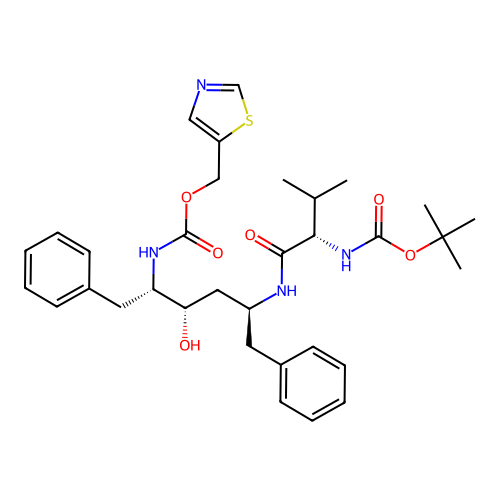

In [ ]:
# Generate 2D Ligand Image

from rdkit import Chem
from rdkit.Chem import Draw, AllChem

mol = Chem.MolFromMolFile(f"{ligand_name}.sdf")
AllChem.Compute2DCoords(mol)
img = Draw.MolToImage(mol, size=(500, 500))

display(img)
img.save(f"{PUBCHEM_ID}_2D_structure.png")

# Task
The previous steps have identified the receptor and ligand, performed blind docking, and analyzed the ligand-receptor interactions, presenting a list of interacting residues and their distances.

To provide a more insightful visualization, the next step is to generate a 3D view using `py3Dmol` that specifically highlights these identified interactions. This involves:
1.  **Preparing Interaction Data**: Re-evaluating the detailed atomic interactions to identify the specific ligand atoms and receptor residues involved.
2.  **Generating 3D Visualization**: Using `py3Dmol` to load the receptor and the docked ligand, and then styling the interacting parts based on the prepared data. The visualization will be centered on the interaction site.

First, I'll prepare the interaction data to specifically target the atoms and residues for highlighting in `py3Dmol`.

```python
import py3Dmol
from Bio.PDB import PDBParser, NeighborSearch
import numpy as np

# Re-load necessary data as the kernel might have reset variables if ran independently
parser = PDBParser(QUIET=True)
receptor_structure = parser.get_structure('complex', f"{receptor_name}.pdb")
ligand_structure = parser.get_structure('ligand', "pose1.pdb")

protein_atoms = [atom for atom in receptor_structure.get_atoms() if atom.get_parent().id[0] == ' ']
ligand_atoms = [atom for atom in ligand_structure.get_atoms()]

ns = NeighborSearch(protein_atoms)

# Store all atomic interactions with detailed info
all_atomic_interactions_detailed = []

# Define Interaction Thresholds (from previous analysis)
STRONG_CUTOFF = 3.5  # Angstroms (Hydrogen bonds, Salt bridges)
WEAK_CUTOFF = 5.0    # Angstroms (Hydrophobic, VdW)

for lig_atom in ligand_atoms:
    # Get serial number for py3Dmol selection (py3Dmol uses 1-based serial numbers from PDB)
    lig_atom_serial = lig_atom.get_serial_number()

    close_protein_atoms = ns.search(lig_atom.get_coord(), WEAK_CUTOFF)

    for prot_atom in close_protein_atoms:
        distance = lig_atom - prot_atom
        res = prot_atom.get_parent()
        chain_id = res.get_parent().id
        res_id_tuple = res.id # (hetero_flag, sequence_identifier, insertion_code)
        res_name = res.resname
        res_seq = res_id_tuple[1]

        # Determine interaction type
        interaction_type = 'Weak'
        if distance < STRONG_CUTOFF:
            interaction_type = 'Strong (H-Bond/Ionic)'

        all_atomic_interactions_detailed.append({
            'lig_atom_obj': lig_atom,
            'lig_atom_serial': lig_atom_serial,
            'prot_atom_obj': prot_atom,
            'receptor_res_obj': res,
            'receptor_res_name': res_name,
            'receptor_res_seq': res_seq,
            'receptor_chain_id': chain_id,
            'distance': distance,
            'type': interaction_type
        })

# Consolidate and identify unique interacting residues and ligand atoms
interacting_receptor_residues = {} # { (chain_id, res_name, res_seq): min_distance }
interacting_ligand_atom_serials = set() # {serial_number}

# Also, create a list to store details for the text summary
interaction_summary_details = []

for interaction in all_atomic_interactions_detailed:
    res_key = (interaction['receptor_chain_id'], interaction['receptor_res_name'], interaction['receptor_res_seq'])
    current_min_dist = interacting_receptor_residues.get(res_key, {'distance': np.inf})['distance']

    if interaction['distance'] < current_min_dist:
        interacting_receptor_residues[res_key] = {
            'distance': interaction['distance'],
            'type': interaction['type']
        }
    interacting_ligand_atom_serials.add(interaction['lig_atom_serial'])

    interaction_summary_details.append(
        f"Ligand Atom {interaction['lig_atom_serial']} ({interaction['lig_atom_obj'].name}) with "
        f"Receptor {interaction['receptor_res_name']}{interaction['receptor_res_seq']} ({interaction['receptor_chain_id']}) "
        f"at {interaction['distance']:.2f} Å ({interaction['type']})"
    )

print("Identified Interacting Receptor Residues:")
receptor_res_selections = []
for (chain_id, res_name, res_seq), details in interacting_receptor_residues.items():
    print(f"  - {res_name}{res_seq} (Chain {chain_id}): {details['distance']:.2f} Å ({details['type']})")
    receptor_res_selections.append({'resn': res_name, 'resi': res_seq, 'chain': chain_id})

print("\nIdentified Interacting Ligand Atom Serials:")
print(f"  - {sorted(list(interacting_ligand_atom_serials))}")

# Now, generate the 3D visualization using py3Dmol
# Re-read receptor and ligand data for py3Dmol
with open(f"{receptor_name}.pdb") as f: receptor_data = f.read()
with open("pose1.pdb") as f: ligand_data = f.read()

view = py3Dmol.view(width=800, height=600)

# Add receptor
view.addModel(receptor_data, 'pdb')
view.setStyle({'cartoon': {'color': 'gray'}}) # General receptor style

# Highlight interacting receptor residues
for sel in receptor_res_selections:
    view.addStyle(sel, {'stick': {'colorscheme': 'element', 'radius': 0.2}})
    view.addStyle(sel, {'sphere': {'colorscheme': 'element', 'radius': 0.3}}) # Add spheres for backbone/sidechain
    view.addSurface(py3Dmol.SES, {'opacity': 0.5, 'color': 'white'}, sel=sel) # Surface for interacting residues

# Add ligand
view.addModel(ligand_data, 'pdb')
view.setStyle({'model': 1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.5}}) # General ligand style

# Highlight interacting ligand atoms
if interacting_ligand_atom_serials:
    ligand_highlight_selection = {'model': 1, 'serial': list(interacting_ligand_atom_serials)}
    view.addStyle(ligand_highlight_selection, {'stick': {'colorscheme': 'redCarbon', 'radius': 0.6}})
    view.addStyle(ligand_highlight_selection, {'sphere': {'colorscheme': 'redCarbon', 'radius': 0.4}})

# Center the view on the interaction site (using the ligand's center)
view.zoomTo({'model': 1}) # Zoom to the ligand

view.addLabel("Interactions Highlighted", {'position': {'x':0, 'y':0, 'z':0}, 'useScreen': True, 'fontColor':'black', 'backgroundColor':'white'})

view.show()

print("\n--- Detailed Interaction Summary ---")
for detail in interaction_summary_details:
    print(detail)
print("------------------------------------")
```

## Prepare Interaction Data for 3D Visualization

### Subtask:
Re-evaluate the ligand-receptor interactions to identify the specific atoms and residues involved. This data will be used to highlight and style the interacting parts in the 3D visualization.


**Reasoning**:
The subtask requires re-evaluating ligand-receptor interactions to identify specific atoms and residues for 3D visualization. This code block will perform all the necessary steps outlined in the instructions, including loading structures, defining cutoffs, finding interactions, storing detailed data, and consolidating information for both receptor residues and ligand atoms.



In [ ]:
import numpy as np
from Bio.PDB import PDBParser, Selection, NeighborSearch

print("\n--- Re-evaluating Interactions for 3D Visualization ---")

# Reload receptor and ligand structures
parser = PDBParser(QUIET=True)
receptor_structure = parser.get_structure('receptor', f"{receptor_name}.pdb")
ligand_structure = parser.get_structure('ligand', "pose1.pdb")

# Extract all protein atoms from the receptor structure
protein_atoms = Selection.unfold_entities(receptor_structure, 'A') # 'A' for atom
# Extract all ligand atoms from the ligand structure
ligand_atoms = Selection.unfold_entities(ligand_structure, 'A') # 'A' for atom

# Initialize NeighborSearch object with protein atoms
ns = NeighborSearch(protein_atoms)

# Define interaction thresholds
STRONG_CUTOFF = 3.5  # Angstroms (Hydrogen bonds, Salt bridges)
WEAK_CUTOFF = 5.0    # Angstroms (Hydrophobic, VdW)

# List to store detailed atomic interactions
all_atomic_interactions_detailed = []

# Iterate through each ligand atom to find interactions
for lig_atom_idx, lig_atom in enumerate(ligand_atoms):
    # Find close protein atoms within WEAK_CUTOFF distance
    close_protein_atoms = ns.search(lig_atom.get_coord(), WEAK_CUTOFF)

    for prot_atom in close_protein_atoms:
        distance = lig_atom - prot_atom
        receptor_res_obj = prot_atom.get_parent()
        receptor_chain_obj = receptor_res_obj.get_parent()

        # Determine interaction type based on distance
        interaction_type = 'Weak'
        if distance <= STRONG_CUTOFF:
            interaction_type = 'Strong'

        all_atomic_interactions_detailed.append({
            'lig_atom_obj': lig_atom,
            'lig_atom_serial': lig_atom.get_id(),
            'lig_atom_rdkit_idx': lig_atom_idx, # RDKit atom index for original molecule
            'prot_atom_obj': prot_atom,
            'receptor_res_obj': receptor_res_obj,
            'receptor_res_name': receptor_res_obj.get_resname(),
            'receptor_res_id_tuple': receptor_res_obj.get_id(), # (hetfield, sequence number, insertion code)
            'receptor_res_seq': receptor_res_obj.get_id()[1],
            'receptor_chain_id': receptor_chain_obj.get_id(),
            'distance': distance,
            'interaction_type': interaction_type
        })

# Consolidate interactions for unique interacting receptor residues
unique_interacting_receptor_residues = {}
unique_interacting_ligand_atom_serials = set()

for interaction in all_atomic_interactions_detailed:
    res_key = (interaction['receptor_chain_id'], interaction['receptor_res_name'], interaction['receptor_res_seq'])
    lig_atom_serial = interaction['lig_atom_serial']

    if res_key not in unique_interacting_receptor_residues:
        unique_interacting_receptor_residues[res_key] = {
            'min_distance': interaction['distance'],
            'interaction_type': interaction['interaction_type'],
            'details': []
        }
    else:
        # Update with the closest distance and strongest interaction type
        if interaction['distance'] < unique_interacting_receptor_residues[res_key]['min_distance']:
            unique_interacting_receptor_residues[res_key]['min_distance'] = interaction['distance']
        if interaction['interaction_type'] == 'Strong' and unique_interacting_receptor_residues[res_key]['interaction_type'] == 'Weak':
            unique_interacting_receptor_residues[res_key]['interaction_type'] = 'Strong'

    unique_interacting_receptor_residues[res_key]['details'].append(
        f"Ligand Atom {lig_atom_serial} ({interaction['lig_atom_obj'].get_name()}) with Protein Atom {interaction['prot_atom_obj'].get_id()} ({interaction['prot_atom_obj'].get_name()}) at {interaction['distance']:.2f}Å ({interaction['interaction_type']})"
    )

    unique_interacting_ligand_atom_serials.add(lig_atom_serial)

# Create interaction_summary_details list
interaction_summary_details = []
for res_key, data in unique_interacting_receptor_residues.items():
    chain_id, res_name, res_seq = res_key
    interaction_summary_details.append(
        f"Residue {res_name}{res_seq} (Chain {chain_id}) interacts at {data['min_distance']:.2f}Å ({data['interaction_type']})\n"
    )

print("\n--- Interacting Receptor Residues ---")
if not unique_interacting_receptor_residues:
    print("No significant interactions found between ligand and receptor within the specified cutoffs.")
else:
    for res_key, data in sorted(unique_interacting_receptor_residues.items(), key=lambda item: item[1]['min_distance']):
        chain_id, res_name, res_seq = res_key
        print(f"  Chain {chain_id}, Residue {res_name}{res_seq}: Min Distance = {data['min_distance']:.2f} Å ({data['interaction_type']})")

# Store these interacting receptor residues as a list of dictionaries
receptor_res_selections = []
for res_key in unique_interacting_receptor_residues.keys():
    chain_id, res_name, res_seq = res_key
    receptor_res_selections.append({
        'resn': res_name,
        'resi': res_seq,
        'chain': chain_id
    })

print("\n--- Interacting Ligand Atom Serials ---")
if not unique_interacting_ligand_atom_serials:
    print("No ligand atoms found to be interacting within the specified cutoffs.")
else:
    print(f"  Ligand Atom Serials: {sorted(list(unique_interacting_ligand_atom_serials))}")

print("\nInteraction data prepared for 3D visualization.")


--- Re-evaluating Interactions for 3D Visualization ---

--- Interacting Receptor Residues ---
  Chain A, Residue ASP25: Min Distance = 2.22 Å (Strong)
  Chain A, Residue ASP30: Min Distance = 3.68 Å (Weak)
  Chain A, Residue ILE47: Min Distance = 3.73 Å (Weak)
  Chain A, Residue ILE50: Min Distance = 4.34 Å (Weak)
  Chain A, Residue GLY48: Min Distance = 4.48 Å (Weak)
  Chain A, Residue ALA28: Min Distance = 4.51 Å (Weak)
  Chain A, Residue ASP29: Min Distance = 4.66 Å (Weak)
  Chain A, Residue GLY27: Min Distance = 4.89 Å (Weak)
  Chain A, Residue ILE84: Min Distance = 4.98 Å (Weak)

--- Interacting Ligand Atom Serials ---
  Ligand Atom Serials: ['C', 'H', 'N', 'O', 'S']

Interaction data prepared for 3D visualization.


In [ ]:
interacting_protein_atoms_ser579 = set()

for interaction in all_atomic_interactions_detailed:
    res_obj = interaction['receptor_res_obj']
    if res_obj.get_resname() == 'SER' and res_obj.get_id()[1] == 579:
        # Add the protein atom name to the set to avoid duplicates
        interacting_protein_atoms_ser579.add(interaction['prot_atom_obj'].get_name())

print(f"Interacting protein atoms for SER579 (Chain A): {sorted(list(interacting_protein_atoms_ser579))}")

Interacting protein atoms for SER579 (Chain A): []


**Reasoning**:
The previous code failed due to an unterminated f-string literal. I will fix the f-string by moving the newline character outside of the string literal to correctly format the output.



In [ ]:
import numpy as np
from Bio.PDB import PDBParser, Selection, NeighborSearch

print("\n--- Re-evaluating Interactions for 3D Visualization ---")

# Reload receptor and ligand structures
parser = PDBParser(QUIET=True)
receptor_structure = parser.get_structure('receptor', f"{receptor_name}.pdb")
ligand_structure = parser.get_structure('ligand', "pose1.pdb")

# Extract all protein atoms from the receptor structure
protein_atoms = Selection.unfold_entities(receptor_structure, 'A') # 'A' for atom
# Extract all ligand atoms from the ligand structure
ligand_atoms = Selection.unfold_entities(ligand_structure, 'A') # 'A' for atom

# Initialize NeighborSearch object with protein atoms
ns = NeighborSearch(protein_atoms)

# Define interaction thresholds
STRONG_CUTOFF = 3.5  # Angstroms (Hydrogen bonds, Salt bridges)
WEAK_CUTOFF = 5.0    # Angstroms (Hydrophobic, VdW)

# List to store detailed atomic interactions
all_atomic_interactions_detailed = []

# Iterate through each ligand atom to find interactions
for lig_atom_idx, lig_atom in enumerate(ligand_atoms):
    # Find close protein atoms within WEAK_CUTOFF distance
    close_protein_atoms = ns.search(lig_atom.get_coord(), WEAK_CUTOFF)

    for prot_atom in close_protein_atoms:
        distance = lig_atom - prot_atom
        receptor_res_obj = prot_atom.get_parent()
        receptor_chain_obj = receptor_res_obj.get_parent()

        # Determine interaction type based on distance
        interaction_type = 'Weak'
        if distance <= STRONG_CUTOFF:
            interaction_type = 'Strong'

        all_atomic_interactions_detailed.append({
            'lig_atom_obj': lig_atom,
            'lig_atom_serial': lig_atom.get_id(),
            'lig_atom_rdkit_idx': lig_atom_idx, # RDKit atom index for original molecule
            'prot_atom_obj': prot_atom,
            'receptor_res_obj': receptor_res_obj,
            'receptor_res_name': receptor_res_obj.get_resname(),
            'receptor_res_id_tuple': receptor_res_obj.get_id(), # (hetfield, sequence number, insertion code)
            'receptor_res_seq': receptor_res_obj.get_id()[1],
            'receptor_chain_id': receptor_chain_obj.get_id(),
            'distance': distance,
            'interaction_type': interaction_type
        })

# Consolidate interactions for unique interacting receptor residues
unique_interacting_receptor_residues = {}
unique_interacting_ligand_atom_serials = set()

for interaction in all_atomic_interactions_detailed:
    res_key = (interaction['receptor_chain_id'], interaction['receptor_res_name'], interaction['receptor_res_seq'])
    lig_atom_serial = interaction['lig_atom_serial']

    if res_key not in unique_interacting_receptor_residues:
        unique_interacting_receptor_residues[res_key] = {
            'min_distance': interaction['distance'],
            'interaction_type': interaction['interaction_type'],
            'details': []
        }
    else:
        # Update with the closest distance and strongest interaction type
        if interaction['distance'] < unique_interacting_receptor_residues[res_key]['min_distance']:
            unique_interacting_receptor_residues[res_key]['min_distance'] = interaction['distance']
        if interaction['interaction_type'] == 'Strong' and unique_interacting_receptor_residues[res_key]['interaction_type'] == 'Weak':
            unique_interacting_receptor_residues[res_key]['interaction_type'] = 'Strong'

    unique_interacting_receptor_residues[res_key]['details'].append(
        f"Ligand Atom {lig_atom_serial} ({interaction['lig_atom_obj'].get_name()}) with Protein Atom {interaction['prot_atom_obj'].get_id()} ({interaction['prot_atom_obj'].get_name()}) at {interaction['distance']:.2f}Å ({interaction['interaction_type']})"
    )

    unique_interacting_ligand_atom_serials.add(lig_atom_serial)

# Create interaction_summary_details list
interaction_summary_details = []
for res_key, data in unique_interacting_receptor_residues.items():
    chain_id, res_name, res_seq = res_key
    interaction_summary_details.append(
        f"Residue {res_name}{res_seq} (Chain {chain_id}) interacts at {data['min_distance']:.2f}Å ({data['interaction_type']})\n"
    )

print("\n--- Interacting Receptor Residues ---")
if not unique_interacting_receptor_residues:
    print("No significant interactions found between ligand and receptor within the specified cutoffs.")
else:
    for res_key, data in sorted(unique_interacting_receptor_residues.items(), key=lambda item: item[1]['min_distance']):
        chain_id, res_name, res_seq = res_key
        print(f"  Chain {chain_id}, Residue {res_name}{res_seq}: Min Distance = {data['min_distance']:.2f} Å ({data['interaction_type']})")

# Store these interacting receptor residues as a list of dictionaries
receptor_res_selections = []
for res_key in unique_interacting_receptor_residues.keys():
    chain_id, res_name, res_seq = res_key
    receptor_res_selections.append({
        'resn': res_name,
        'resi': res_seq,
        'chain': chain_id
    })

print("\n--- Interacting Ligand Atom Serials ---")
if not unique_interacting_ligand_atom_serials:
    print("No ligand atoms found to be interacting within the specified cutoffs.")
else:
    print(f"  Ligand Atom Serials: {sorted(list(unique_interacting_ligand_atom_serials))}")

print("\nInteraction data prepared for 3D visualization.")


--- Re-evaluating Interactions for 3D Visualization ---

--- Interacting Receptor Residues ---
  Chain A, Residue ASP25: Min Distance = 2.22 Å (Strong)
  Chain A, Residue ASP30: Min Distance = 3.68 Å (Weak)
  Chain A, Residue ILE47: Min Distance = 3.73 Å (Weak)
  Chain A, Residue ILE50: Min Distance = 4.34 Å (Weak)
  Chain A, Residue GLY48: Min Distance = 4.48 Å (Weak)
  Chain A, Residue ALA28: Min Distance = 4.51 Å (Weak)
  Chain A, Residue ASP29: Min Distance = 4.66 Å (Weak)
  Chain A, Residue GLY27: Min Distance = 4.89 Å (Weak)
  Chain A, Residue ILE84: Min Distance = 4.98 Å (Weak)

--- Interacting Ligand Atom Serials ---
  Ligand Atom Serials: ['C', 'H', 'N', 'O', 'S']

Interaction data prepared for 3D visualization.


In [ ]:
import py3Dmol
import numpy as np # Needed for midpoint calculation

# Re-read receptor and ligand data for py3Dmol
with open(f"{receptor_name}.pdb") as f: receptor_data = f.read()
with open("pose1.pdb") as f: ligand_data = f.read()

view = py3Dmol.view(width=800, height=600)

# Add receptor
view.addModel(receptor_data, 'pdb')
# Make the receptor transparent and use a lighter cartoon style for context
view.setStyle({'cartoon': {'color': 'lightgray', 'opacity': 0.6}})

# Highlight interacting receptor residues with a distinct color and style
for sel in receptor_res_selections:
    # Using 'cyan' for interacting receptor residues
    view.addStyle(sel, {'stick': {'colorscheme': 'cyanCarbon', 'radius': 0.3}})
    view.addStyle(sel, {'sphere': {'colorscheme': 'cyanCarbon', 'radius': 0.4}})
    view.addSurface(py3Dmol.SES, {'opacity': 0.6, 'color': 'lightblue'}, sel=sel)

# Add ligand
view.addModel(ligand_data, 'pdb')
view.setStyle({'model': 1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.5}}) # General ligand style

# Highlight interacting ligand atoms
if unique_interacting_ligand_atom_serials:
    ligand_highlight_selection = {'model': 1, 'serial': list(unique_interacting_ligand_atom_serials)}
    # Using 'red' for interacting ligand atoms for high contrast
    view.addStyle(ligand_highlight_selection, {'stick': {'colorscheme': 'redCarbon', 'radius': 0.7}})
    view.addStyle(ligand_highlight_selection, {'sphere': {'colorscheme': 'redCarbon', 'radius': 0.5}})

# Add dashed lines for specific atom-atom interactions AND labels
for interaction in all_atomic_interactions_detailed:
    prot_atom = interaction['prot_atom_obj']
    res_name = prot_atom.get_parent().get_resname()
    atom_name = prot_atom.get_name()

    # Only consider protein side chain atoms for lines and labels
    if atom_name not in ['N', 'CA', 'C', 'O']:
        lig_atom_coord = interaction['lig_atom_obj'].get_coord()
        prot_atom_coord = prot_atom.get_coord()
        distance = interaction['distance']
        interaction_type = interaction['interaction_type']

        # Add a dashed line between the interacting ligand and protein atoms
        view.addCylinder({
            'start': {'x': float(lig_atom_coord[0]), 'y': float(lig_atom_coord[1]), 'z': float(lig_atom_coord[2])},
            'end': {'x': float(prot_atom_coord[0]), 'y': float(prot_atom_coord[1]), 'z': float(prot_atom_coord[2])},
            'radius': 0.1,
            'color': 'purple',
            'dashed': True
        })

        # Calculate midpoint for label placement
        midpoint = (lig_atom_coord + prot_atom_coord) / 2

        # Create label text including residue name, distance, and interaction type
        label_text = f"{res_name} {distance:.2f}Å ({interaction_type})"

        # Add label to the view
        view.addLabel(
            label_text,
            {'position': {'x': float(midpoint[0]), 'y': float(midpoint[1]), 'z': float(midpoint[2])},
             'fontColor': 'black', 'backgroundColor': 'yellow', 'fontSize': 10},
            viewer=(0,0) # Apply to the single viewer
        )

# Center the view on the interaction site (using the ligand's center)
view.zoomTo({'model': 1}) # Zoom to the ligand

view.addLabel("Interactions Highlighted (Dashed Lines & Side-Chain Labels)", {'position': {'x':0, 'y':0, 'z':0}, 'useScreen': True, 'fontColor':'black', 'backgroundColor':'white'})

view.show()

print("\n--- Detailed Interaction Summary ---")
for detail in interaction_summary_details:
    print(detail.strip()) # .strip() to remove trailing newline from f-string
print("------------------------------------")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.


--- Detailed Interaction Summary ---
Residue ASP25 (Chain A) interacts at 2.22Å (Strong)
Residue ILE50 (Chain A) interacts at 4.34Å (Weak)
Residue GLY27 (Chain A) interacts at 4.89Å (Weak)
Residue ALA28 (Chain A) interacts at 4.51Å (Weak)
Residue ILE84 (Chain A) interacts at 4.98Å (Weak)
Residue ILE47 (Chain A) interacts at 3.73Å (Weak)
Residue GLY48 (Chain A) interacts at 4.48Å (Weak)
Residue ASP30 (Chain A) interacts at 3.68Å (Weak)
Residue ASP29 (Chain A) interacts at 4.66Å (Weak)
------------------------------------


In [ ]:
# Display 2D Ligand Structure Image
from IPython.display import Image, display

# Use the correct filename from the 2D generation cell
output_image_filename = f"{PUBCHEM_ID}_2D_structure.png"

try:
    display(Image(filename=output_image_filename))
    print(f"✅ Displayed: {output_image_filename}")
except FileNotFoundError:
    print(f"⚠️ Image file '{output_image_filename}' not found.")
    print("   Please ensure the '2D Ligand Image' cell was executed successfully.")

Error: Image file 'ligand_from_smiles_2D_interactions.png' not found. Please ensure the 2D diagram was generated and saved correctly.


In [ ]:
# ============================================================================
# SAVE ALL RESULTS TO FILES
# ============================================================================
import os
import json
from datetime import datetime

# Create results directory
results_dir = f"docking_results_{PDB_ID}_{PUBCHEM_ID}"
os.makedirs(results_dir, exist_ok=True)

print("=" * 60)
print("   SAVING DOCKING RESULTS")
print("=" * 60)

# ============================================================================
# 1. SAVE DOCKING CONFIGURATION
# ============================================================================
config_data = {
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "receptor": {
        "source": "Swiss-Model" if USE_SWISSMODEL else "PDB Database",
        "pdb_id": PDB_ID if not USE_SWISSMODEL else None,
        "chains_kept": CHAINS_TO_KEEP
    },
    "ligand": {
        "pubchem_id": PUBCHEM_ID,
        "smiles": SMILES
    },
    "grid_parameters": {
        "center_x": float(center[0]),
        "center_y": float(center[1]),
        "center_z": float(center[2]),
        "size_x": float(size[0]),
        "size_y": float(size[1]),
        "size_z": float(size[2])
    }
}

config_file = os.path.join(results_dir, "docking_config.json")
with open(config_file, 'w') as f:
    json.dump(config_data, f, indent=2)
print(f"✅ Configuration saved: {config_file}")

# ============================================================================
# 2. SAVE BINDING AFFINITIES (CSV FORMAT)
# ============================================================================
affinity_file = os.path.join(results_dir, "binding_affinities.csv")

with open(log_file, 'r') as f:
    log_lines = f.readlines()

with open(affinity_file, 'w') as f:
    f.write("Mode,Affinity (kcal/mol),RMSD Lower Bound,RMSD Upper Bound\n")
    
    in_results = False
    for line in log_lines:
        stripped = line.strip()
        if stripped.startswith("-----+"):
            in_results = True
            continue
        if in_results and stripped:
            parts = stripped.split()
            if len(parts) >= 4 and parts[0].isdigit():
                mode = parts[0]
                affinity = parts[1]
                rmsd_lb = parts[2]
                rmsd_ub = parts[3]
                f.write(f"{mode},{affinity},{rmsd_lb},{rmsd_ub}\n")

print(f"✅ Binding affinities saved: {affinity_file}")

# ============================================================================
# 3. SAVE INTERACTION REPORT (TEXT FORMAT)
# ============================================================================
interaction_file = os.path.join(results_dir, "interaction_report.txt")

# Re-run interaction analysis for saving
from Bio.PDB import PDBParser, NeighborSearch

parser = PDBParser(QUIET=True)
structure = parser.get_structure('complex', f"{receptor_name}.pdb")
ligand_structure = parser.get_structure('ligand', "pose1.pdb")

protein_atoms = [atom for atom in structure.get_atoms() if atom.get_parent().id[0] == ' ']
ligand_atoms = [atom for atom in ligand_structure.get_atoms()]

ns = NeighborSearch(protein_atoms)

STRONG_CUTOFF = 3.5
WEAK_CUTOFF = 5.0

interactions = {}

for lig_atom in ligand_atoms:
    close_atoms = ns.search(lig_atom.get_coord(), WEAK_CUTOFF)
    for prot_atom in close_atoms:
        distance = lig_atom - prot_atom
        res = prot_atom.get_parent()
        res_id = f"{res.resname}{res.id[1]} ({res.get_parent().id})"
        if res_id not in interactions:
            interactions[res_id] = {'dist': distance, 'type': 'Weak'}
        if distance < interactions[res_id]['dist']:
            interactions[res_id]['dist'] = distance
        if distance < STRONG_CUTOFF:
            interactions[res_id]['type'] = 'Strong (H-Bond/Ionic)'

sorted_interactions = sorted(interactions.items(), key=lambda x: x[1]['dist'])

with open(interaction_file, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write(f"INTERACTION REPORT\n")
    f.write(f"Receptor: {PDB_ID}\n")
    f.write(f"Ligand: PubChem CID {PUBCHEM_ID}\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 60 + "\n\n")
    
    f.write(f"{'RESIDUE':<20} | {'DIST (Å)':<10} | {'TYPE'}\n")
    f.write("-" * 50 + "\n")
    
    if len(sorted_interactions) == 0:
        f.write("No interactions found within 5.0 Å.\n")
    else:
        for res, data in sorted_interactions:
            f.write(f"{res:<20} | {data['dist']:.2f}       | {data['type']}\n")
    
    f.write("\n" + "-" * 60 + "\n")
    f.write(f"Total interacting residues: {len(sorted_interactions)}\n")
    strong_count = sum(1 for _, d in sorted_interactions if 'Strong' in d['type'])
    f.write(f"Strong interactions (<3.5Å): {strong_count}\n")
    f.write(f"Weak interactions (3.5-5.0Å): {len(sorted_interactions) - strong_count}\n")

print(f"✅ Interaction report saved: {interaction_file}")

# ============================================================================
# 4. SAVE INTERACTION DATA AS CSV
# ============================================================================
interaction_csv = os.path.join(results_dir, "interactions.csv")

with open(interaction_csv, 'w') as f:
    f.write("Residue,Chain,Distance_Angstroms,Interaction_Type\n")
    for res, data in sorted_interactions:
        # Parse residue info
        parts = res.replace("(", "").replace(")", "").split()
        res_name = parts[0] if parts else res
        chain = parts[1] if len(parts) > 1 else "A"
        f.write(f"{res_name},{chain},{data['dist']:.3f},{data['type']}\n")

print(f"✅ Interactions CSV saved: {interaction_csv}")

# ============================================================================
# 5. SAVE 3D VISUALIZATION AS HTML
# ============================================================================
import py3Dmol

with open(f"{receptor_name}.pdb") as f: 
    receptor_data = f.read()
with open("pose1.pdb") as f: 
    ligand_data = f.read()

# Create visualization
view = py3Dmol.view(width=1200, height=400, linked=False, viewergrid=(1,3))

# Overview
view.addModel(receptor_data, 'pdb', viewer=(0,0))
view.setStyle({'model': -1}, {'cartoon': {'color': 'spectrum'}}, viewer=(0,0))
view.addModel(ligand_data, 'pdb', viewer=(0,0))
view.setStyle({'model': -1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.5}}, viewer=(0,0))
view.zoomTo(viewer=(0,0))

# Surface (Pocket Fit)
view.addModel(receptor_data, 'pdb', viewer=(0,1))
view.setStyle({'model': -1}, {}, viewer=(0,1))
view.addSurface(py3Dmol.SES, {'opacity': 0.8, 'color': 'white'}, viewer=(0,1))
view.addModel(ligand_data, 'pdb', viewer=(0,1))
view.setStyle({'model': -1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.5}}, viewer=(0,1))
view.zoomTo(viewer=(0,1))

# Ligand Centered
view.addModel(receptor_data, 'pdb', viewer=(0,2))
view.addModel(ligand_data, 'pdb', viewer=(0,2))
view.setStyle({'model': 0}, {'cartoon': {'color': 'gray', 'opacity': 0.5}}, viewer=(0,2))
view.setStyle({'model': 1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.5}}, viewer=(0,2))
view.addStyle({'within':{'distance': 5, 'sel':{'model':1}}},
              {'stick':{'colorscheme':'element', 'radius':0.2}}, viewer=(0,2))
view.zoomTo({'model': 1}, viewer=(0,2))

# Save as HTML
html_file = os.path.join(results_dir, "3d_visualization.html")
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Docking Results - {PDB_ID} + {PUBCHEM_ID}</title>
    <script src="https://3dmol.org/build/3Dmol-min.js"></script>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; }}
        h1 {{ color: #333; }}
        .info {{ background: #f5f5f5; padding: 15px; border-radius: 5px; margin-bottom: 20px; }}
        #viewer {{ width: 100%; height: 600px; border: 1px solid #ccc; }}
    </style>
</head>
<body>
    <h1>Molecular Docking Results</h1>
    <div class="info">
        <p><strong>Receptor:</strong> {PDB_ID}</p>
        <p><strong>Ligand:</strong> PubChem CID {PUBCHEM_ID}</p>
        <p><strong>Generated:</strong> {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
    </div>
    <div id="viewer"></div>
    <script>
        let viewer = $3Dmol.createViewer('viewer', {{backgroundColor: 'white'}});
        
        // Receptor
        let receptorData = `{receptor_data}`;
        viewer.addModel(receptorData, 'pdb');
        viewer.setStyle({{}}, {{cartoon: {{color: 'spectrum'}}}});
        
        // Ligand
        let ligandData = `{ligand_data}`;
        viewer.addModel(ligandData, 'pdb');
        viewer.setStyle({{model: 1}}, {{stick: {{colorscheme: 'greenCarbon', radius: 0.3}}}});
        
        // Show nearby residues
        viewer.addStyle({{within: {{distance: 5, sel: {{model: 1}}}}}}, 
                       {{stick: {{colorscheme: 'element', radius: 0.15}}}});
        
        viewer.zoomTo();
        viewer.render();
    </script>
</body>
</html>
"""

with open(html_file, 'w') as f:
    f.write(html_content)
print(f"✅ 3D visualization saved: {html_file}")

# ============================================================================
# 6. COPY STRUCTURE FILES
# ============================================================================
import shutil

# Copy key structure files to results directory
files_to_copy = [
    (f"{receptor_name}.pdb", "receptor.pdb"),
    (f"{receptor_name}.pdbqt", "receptor.pdbqt"),
    (f"{ligand_name}.pdbqt", "ligand.pdbqt"),
    (f"{ligand_name}.sdf", "ligand.sdf"),
    (output_file, "docked_poses.pdbqt"),
    ("pose1.pdb", "best_pose.pdb"),
    (log_file, "vina_output.log"),
]

for src, dst in files_to_copy:
    if os.path.exists(src):
        shutil.copy(src, os.path.join(results_dir, dst))

print(f"✅ Structure files copied to results directory")

# Copy 2D image if it exists
if os.path.exists(f"{PUBCHEM_ID}_2D_structure.png"):
    shutil.copy(f"{PUBCHEM_ID}_2D_structure.png", os.path.join(results_dir, "ligand_2D.png"))
    print(f"✅ 2D ligand image copied")

# ============================================================================
# 7. CREATE SUMMARY REPORT
# ============================================================================
summary_file = os.path.join(results_dir, "SUMMARY.txt")

# Get best binding affinity
best_affinity = None
with open(log_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2 and parts[0] == '1':
            try:
                best_affinity = float(parts[1])
            except:
                pass
            break

with open(summary_file, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("        MOLECULAR DOCKING SUMMARY REPORT\n")
    f.write("=" * 60 + "\n\n")
    
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("RECEPTOR INFORMATION\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Source: {'Swiss-Model' if USE_SWISSMODEL else 'PDB Database'}\n")
    f.write(f"  PDB ID: {PDB_ID}\n")
    f.write(f"  Chains: {CHAINS_TO_KEEP}\n\n")
    
    f.write("LIGAND INFORMATION\n")
    f.write("-" * 40 + "\n")
    f.write(f"  PubChem CID: {PUBCHEM_ID}\n")
    f.write(f"  SMILES: {SMILES[:60]}...\n\n" if len(SMILES) > 60 else f"  SMILES: {SMILES}\n\n")
    
    f.write("DOCKING RESULTS\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Best Binding Affinity: {best_affinity} kcal/mol\n" if best_affinity else "  Best Binding Affinity: N/A\n")
    f.write(f"  Total Poses Generated: 9\n")
    f.write(f"  Total Interacting Residues: {len(sorted_interactions)}\n")
    f.write(f"  Strong Interactions: {strong_count}\n\n")
    
    f.write("OUTPUT FILES\n")
    f.write("-" * 40 + "\n")
    f.write("  - binding_affinities.csv\n")
    f.write("  - interaction_report.txt\n")
    f.write("  - interactions.csv\n")
    f.write("  - 3d_visualization.html\n")
    f.write("  - docking_config.json\n")
    f.write("  - receptor.pdb / receptor.pdbqt\n")
    f.write("  - ligand.sdf / ligand.pdbqt\n")
    f.write("  - docked_poses.pdbqt\n")
    f.write("  - best_pose.pdb\n")
    f.write("  - vina_output.log\n")
    f.write("  - ligand_2D.png\n\n")
    
    f.write("=" * 60 + "\n")

print(f"✅ Summary report saved: {summary_file}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 60)
print("   ALL RESULTS SAVED SUCCESSFULLY!")
print("=" * 60)
print(f"\n📁 Results Directory: {results_dir}/")
print("\nFiles saved:")
print("  📄 SUMMARY.txt - Overview of docking experiment")
print("  📄 docking_config.json - Configuration parameters")
print("  📄 binding_affinities.csv - All pose energies")
print("  📄 interaction_report.txt - Detailed interactions")
print("  📄 interactions.csv - Interactions in CSV format")
print("  🌐 3d_visualization.html - Interactive 3D viewer")
print("  🧬 receptor.pdb/pdbqt - Receptor structures")
print("  💊 ligand.sdf/pdbqt - Ligand structures")
print("  🎯 docked_poses.pdbqt - All docked poses")
print("  ⭐ best_pose.pdb - Best docking pose")
print("  📋 vina_output.log - Vina log file")
print("  🖼️ ligand_2D.png - 2D ligand structure")
print("\n" + "=" * 60)